In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/euclidean_distances.csv')
df1['condition'] = 'wiii8'


df2 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/euclidean_distances.csv')
df2['condition'] = 'anosmic'


df3 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/euclidean_distances.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/euclidean_distances.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/euclidean_distances.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

condition_colors = {
    'wiii8': '#385491',
    'anosmic': '#be0f0a',
    '9047': '#e7533a',
    '23129': '#fc8c59',
    '33300': '#fead61',
}

mutants = ['anosmic', '9047', '23129', '33300']


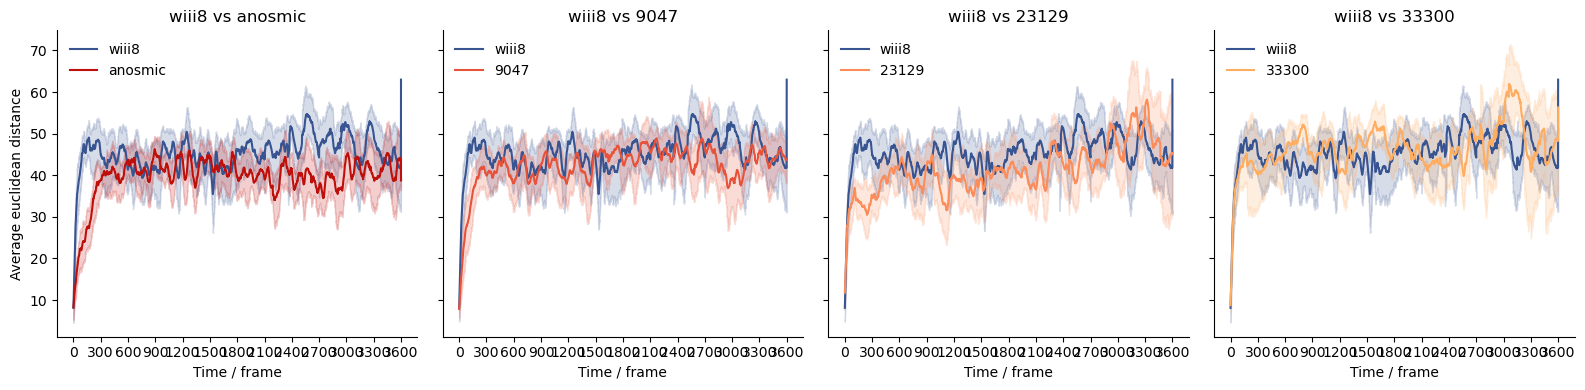

In [3]:
# average distance trace over time

distance_summary = df.groupby(['condition', 'file', 'time']).agg(
    average_distance=('average_distance', 'mean'),
).reset_index()


fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)

tick_start = int(np.floor(distance_summary['time'].min() / 300) * 300)
tick_end = int(np.ceil(distance_summary['time'].max() / 300) * 300)

for ax, mutant in zip(axes, mutants):
    comparison = distance_summary[
        distance_summary['condition'].isin(['wiii8', mutant])
    ]

    sns.lineplot(
        data=comparison,
        x='time',
        y='average_distance',
        hue='condition',
        hue_order=['wiii8', mutant],
        palette=condition_colors,
        errorbar=('ci', 95),
        ax=ax,
    )

    ax.set_xticks(np.arange(tick_start, tick_end + 300, 300))
    ax.set_title(f'wiii8 vs {mutant}', fontsize=12)
    ax.set_xlabel('Time / frame')
    ax.set_ylabel('Average euclidean distance' if ax is axes[0] else '')
    ax.legend(title=None, frameon=False)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


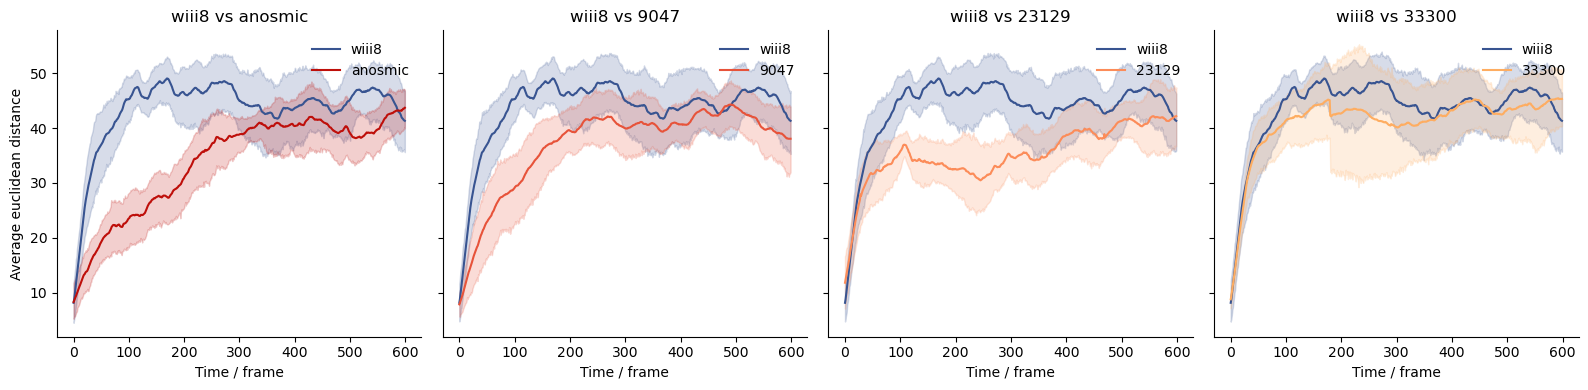

In [4]:
# average distance trace over time

distance_summary_2 = df[df['time'] < 600]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)

for ax, mutant in zip(axes, mutants):
    comparison = distance_summary_2[
        distance_summary_2['condition'].isin(['wiii8', mutant])
    ]

    sns.lineplot(
        data=comparison,
        x='time',
        y='average_distance',
        hue='condition',
        hue_order=['wiii8', mutant],
        palette=condition_colors,
        errorbar=('ci', 95),
        ax=ax,
    )

    ax.set_title(f'wiii8 vs {mutant}', fontsize=12)
    ax.set_xlabel('Time / frame')
    ax.set_ylabel('Average euclidean distance' if ax is axes[0] else '')
    ax.legend(title=None, frameon=False)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()
